# Incipit: il metodo Monte Carlo e la sua implementazione in finanza

Il metodo Monte Carlo è una tecnica stocastica basata sulla simulazione di scenari casuali per stimare quantità attese quando una soluzione analitica è difficile o impossibile. In finanza viene usato per valutare strumenti derivati, misurare il rischio di portafoglio e stimare metriche come Value at Risk o aspettative di payoff sotto dinamiche complesse degli asset. L'approccio consiste nel costruire un modello dinamico degli asset, generare molte traiettorie casuali coerenti con quel modello, calcolare il risultato di interesse su ciascuna traiettoria e ottenere una stima tramite media (eventualmente scontata) insieme a una stima dell'errore.

Passaggi tipici
- Definire il modello sottostante (es. GBM, modelli con salto, modelli locali/stocastici della volatilità).
- Discretizzare la dinamica nel tempo e scegliere il passo di integrazione.
- Generare numeri casuali/gaussiani e simulare N traiettorie.
- Calcolare il payoff o la misura di rischio per ogni traiettoria.
- Mediare i risultati, applicare fattori di sconto e stimare l'incertezza statistica (errore standard, intervalli di confidenza).

Considerazioni pratiche
- Scelta e calibrazione del modello ai dati di mercato.
- Tecniche di riduzione della varianza (antithetic variates, control variates, stratification, importance sampling).
- Controllo dell'errore di discretizzazione e del numero di traiettorie richiesto per la precisione desiderata.
- Efficienza computazionale: parallelizzazione e uso di GPU per simulazioni massicce.
- Verifica e backtesting: confrontare stime Monte Carlo con soluzioni note, benchmark e dati reali.

Questo incipit introduce il quadro concettuale necessario per implementare e valutare un motore Monte Carlo in applicazioni finanziarie.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri simulazione
S0 = 100      # prezzo iniziale asset
mu = 0.05     # rendimento atteso
sigma = 0.2   # volatilità
T = 1         # orizzonte temporale (anni)
N = 252       # numero di passi (giorni)
M = 10**4     # numero di traiettorie

dt = T / N
# Simulazione Monte Carlo di un processo Geometrico Browniano
S = np.zeros((M, N+1))
S[:,0] = S0
for t in range(1, N+1):
    Z = np.random.randn(M)
    S[:,t] = S[:,t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

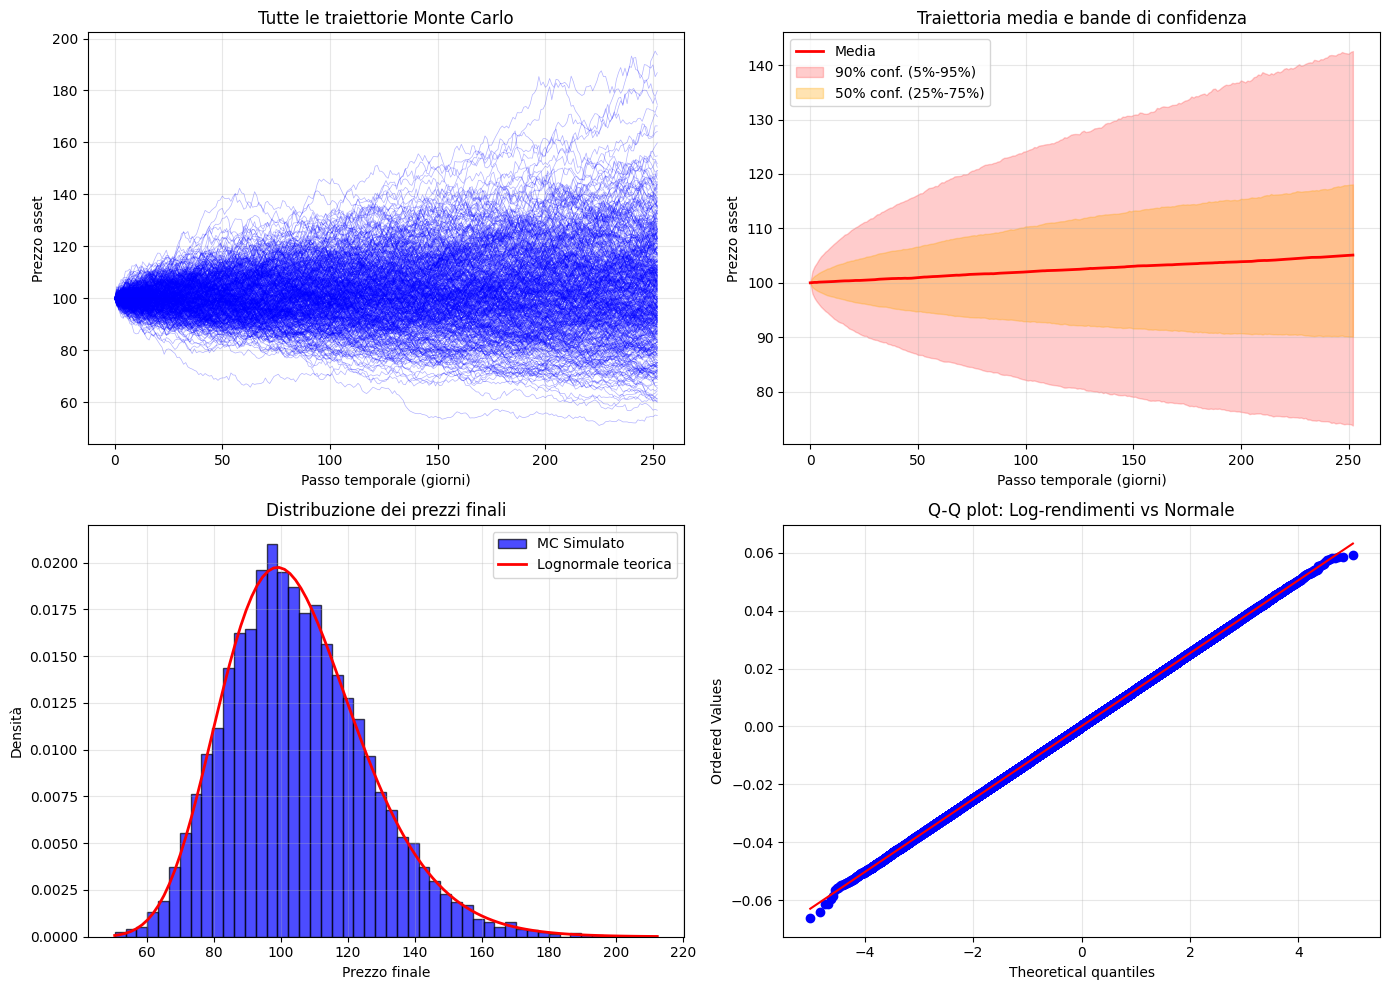


STATISTICHE DELLA SIMULAZIONE MONTE CARLO

Parametri input:
  S0 (prezzo iniziale):     100
  mu (drift annuale):       0.0500
  sigma (volatilità):       0.2000
  T (orizzonte temporale):  1 anni
  N (passi temporali):      252
  M (numero traiettorie):   10000

Prezzo finale (distribuzione empirica):
  Media:                    105.09
  Std Dev:                  21.11
  Min:                      50.41
  Max:                      212.29
  Mediana:                  103.10
  Percentile 5%:            73.76
  Percentile 95%:           142.60

Valori attesi teorici:
  Sotto misura P (mu=0.05):  105.13
  Sotto misura Q (r=0.05):    105.13
  Prezzo simulato medio:    105.09

Errore statistico:
  Standard Error (media):   0.2111
  Intervallo confidenza 95%: [104.68, 105.51]



In [2]:
import scipy.stats as stats

# ============================================================================
# 1. VISUALIZZAZIONE: Traiettorie e Percentili
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1a. Tutte le traiettorie (o sottoinsieme se troppo numerose)
ax = axes[0, 0]
if M > 1000:
    # Plotta un sottoinsieme per chiarezza
    indices = np.random.choice(M, size=min(500, M), replace=False)
    ax.plot(S[indices, :].T, lw=0.5, alpha=0.3, color='blue')
else:
    ax.plot(S.T, lw=0.5, alpha=0.5, color='blue')
ax.set_title('Tutte le traiettorie Monte Carlo')
ax.set_xlabel('Passo temporale (giorni)')
ax.set_ylabel('Prezzo asset')
ax.grid(True, alpha=0.3)

# 1b. Traiettoria media e bande di confidenza (percentili)
ax = axes[0, 1]
mean_traj = np.mean(S, axis=0)
percentile_5 = np.percentile(S, 5, axis=0)
percentile_95 = np.percentile(S, 95, axis=0)
percentile_25 = np.percentile(S, 25, axis=0)
percentile_75 = np.percentile(S, 75, axis=0)
time_steps = np.arange(N+1)

ax.plot(time_steps, mean_traj, 'r-', lw=2, label='Media')
ax.fill_between(time_steps, percentile_5, percentile_95, alpha=0.2, color='red', label='90% conf. (5%-95%)')
ax.fill_between(time_steps, percentile_25, percentile_75, alpha=0.3, color='orange', label='50% conf. (25%-75%)')
ax.set_title('Traiettoria media e bande di confidenza')
ax.set_xlabel('Passo temporale (giorni)')
ax.set_ylabel('Prezzo asset')
ax.legend()
ax.grid(True, alpha=0.3)

# 1c. Distribuzione dei prezzi finali (istogramma vs teorica)
ax = axes[1, 0]
S_final = S[:, -1]
ax.hist(S_final, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black', label='MC Simulato')

# Sovrapponi la distribuzione log-normale teorica
S_final_sorted = np.sort(S_final)
# Sotto GBM: ln(S_T) ~ N(ln(S0) + (mu - sigma^2/2)*T, sigma^2*T)
mean_log = np.log(S0) + (mu - 0.5 * sigma**2) * T
std_log = sigma * np.sqrt(T)
x_range = np.linspace(S_final_sorted.min(), S_final_sorted.max(), 100)
pdf_lognormal = stats.lognorm.pdf(x_range, s=std_log, scale=np.exp(mean_log))
ax.plot(x_range, pdf_lognormal, 'r-', lw=2, label='Lognormale teorica')
ax.set_title('Distribuzione dei prezzi finali')
ax.set_xlabel('Prezzo finale')
ax.set_ylabel('Densità')
ax.legend()
ax.grid(True, alpha=0.3)

# 1d. Q-Q plot: Verifica della normalità dei log-rendimenti
ax = axes[1, 1]
log_returns = np.diff(np.log(S), axis=1)
log_returns_flat = log_returns.flatten()
stats.probplot(log_returns_flat, dist="norm", plot=ax)
ax.set_title('Q-Q plot: Log-rendimenti vs Normale')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 2. STATISTICHE DESCRITTIVE
# ============================================================================
print("\n" + "="*70)
print("STATISTICHE DELLA SIMULAZIONE MONTE CARLO")
print("="*70)
print(f"\nParametri input:")
print(f"  S0 (prezzo iniziale):     {S0}")
print(f"  mu (drift annuale):       {mu:.4f}")
print(f"  sigma (volatilità):       {sigma:.4f}")
print(f"  T (orizzonte temporale):  {T} anni")
print(f"  N (passi temporali):      {N}")
print(f"  M (numero traiettorie):   {M}")

print(f"\nPrezzo finale (distribuzione empirica):")
print(f"  Media:                    {np.mean(S_final):.2f}")
print(f"  Std Dev:                  {np.std(S_final):.2f}")
print(f"  Min:                      {np.min(S_final):.2f}")
print(f"  Max:                      {np.max(S_final):.2f}")
print(f"  Mediana:                  {np.median(S_final):.2f}")
print(f"  Percentile 5%:            {np.percentile(S_final, 5):.2f}")
print(f"  Percentile 95%:           {np.percentile(S_final, 95):.2f}")

# Valore atteso teorico sotto la misura risk-neutral (r al posto di mu)
r = 0.05  # Assumiamo un tasso risk-free del 5% (modificabile)
expected_price_rn = S0 * np.exp(r * T)
expected_price_real = S0 * np.exp(mu * T)
print(f"\nValori attesi teorici:")
print(f"  Sotto misura P (mu={mu}):  {expected_price_real:.2f}")
print(f"  Sotto misura Q (r={r}):    {expected_price_rn:.2f}")
print(f"  Prezzo simulato medio:    {np.mean(S_final):.2f}")

# Errore di stima (Standard Error)
standard_error = np.std(S_final) / np.sqrt(M)
print(f"\nErrore statistico:")
print(f"  Standard Error (media):   {standard_error:.4f}")
print(f"  Intervallo confidenza 95%: [{np.mean(S_final) - 1.96*standard_error:.2f}, {np.mean(S_final) + 1.96*standard_error:.2f}]")

print("\n" + "="*70)